# Data Quality Assessment & Preprocessing  
## UCI Heart Disease Dataset

## 1. Introduction

The UCI Heart Disease dataset contains clinical and demographic data used to assess the presence of heart disease in patients.

This dataset includes medical measurements such as blood pressure (mm Hg), cholesterol level (mg/dL), heart rate (beats per minute), and ECG results.

Source: Kaggle (Originally from UCI Machine Learning Repository)
Domain: Healthcare / Cardiology

The target variable (num) indicates the presence and severity of heart disease.

## 2. Dataset Description

The dataset contains clinical and demographic information used to assess the presence of heart disease.
It includes cardiovascular measurements such as resting blood pressure (mm Hg), serum cholesterol (mg/dL), maximum heart rate (beats per minute), and ECG-related attributes.

Source: Kaggle (originally from UCI Machine Learning Repository).
Target variable: num (0–4) indicates heart disease diagnosis severity.

## 3. Column Description & Measurement Units

Below are examples of key numeric columns and their measurement units:

| Column   | Description                         | Unit |
|---------|-------------------------------------|------|
| age     | Age of patient                      | years |
| trestbps| Resting blood pressure              | mm Hg |
| chol    | Serum cholesterol                   | mg/dL |
| thalch  | Maximum heart rate achieved         | beats per minute |
| oldpeak | ST depression induced by exercise   | mm |
| ca      | Number of major vessels             | count |
| num     | Heart disease diagnosis severity    | 0–4 |

## 4. Import Libraries

We import the required Python libraries for data handling and visualization.

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 5. Load Dataset

Load the dataset file and preview the first few rows to verify it loaded correctly.

In [86]:
df = pd.read_csv("heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 6. Data Overview

This section provides a general overview of the dataset including its size, data types, and summary statistics.

In [87]:
df.shape

(920, 16)

In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [89]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## 7. Data Quality Assessment

We check for common data quality issues such as missing values and duplicated rows.

### 7.1 Missing Values

Missing values can affect analysis and modeling. We count missing values per column.

In [90]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

### 7.2 Duplicate Records

Duplicates may bias analysis. We check how many duplicated rows exist.

In [91]:
df.duplicated().sum()

np.int64(0)

## 8. Data Cleaning

We perform basic cleaning by:
1) removing irrelevant columns (e.g., id), and
2) handling missing values to ensure consistent preprocessing steps.

In [92]:
df = df.drop(columns=['id'])

In [93]:
df = pd.get_dummies(df, drop_first=True)

### 8.1 Handling Missing Values

We remove rows containing missing values to ensure scaling methods work correctly.

In [94]:
df = df.dropna()
df.isnull().sum()

age                         0
trestbps                    0
chol                        0
thalch                      0
oldpeak                     0
ca                          0
num                         0
sex_Male                    0
dataset_Hungary             0
dataset_Switzerland         0
dataset_VA Long Beach       0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
fbs_True                    0
restecg_normal              0
restecg_st-t abnormality    0
exang_True                  0
slope_flat                  0
slope_upsloping             0
thal_normal                 0
thal_reversable defect      0
dtype: int64

In this dataset, missing values were handled by removing rows using `dropna()`.

This method was selected because:
- the dataset size is sufficient,
- the number of missing values is small,
- and removing rows simplifies the preprocessing process.

This ensures that no artificial values are introduced into the dataset.


## 9. Outlier Detection
### 9.1 Boxplot Visualization

We use boxplots to visually detect potential outliers in numerical features.


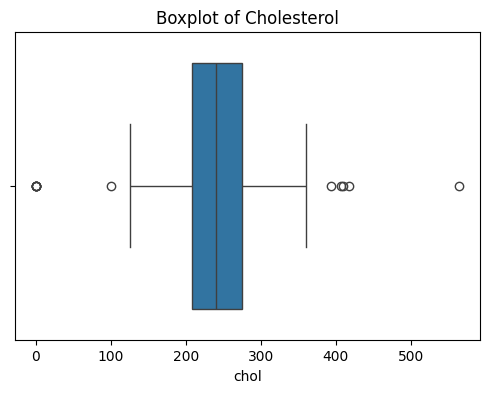

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x=df["chol"])
plt.title("Boxplot of Cholesterol")
plt.show()

### 9.2 Detect Outliers using IQR

The Interquartile Range (IQR) method is used to detect outliers.

- Q1 = 25th percentile  
- Q3 = 75th percentile  
- IQR = Q3 - Q1  

Outliers are values outside:
- Lower bound = Q1 - 1.5 × IQR  
- Upper bound = Q3 + 1.5 × IQR

In [96]:
Q1 = df["chol"].quantile(0.25)
Q3 = df["chol"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["chol"] < lower_bound) | (df["chol"] > upper_bound)]

print("Number of outliers:", outliers.shape[0])
outliers.head()

Number of outliers: 12


,age,trestbps,chol,thalch,oldpeak,ca,num,sex_Male,dataset_Hungary,dataset_Switzerland,...,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
48,65,140.0,417.0,157.0,0.8,1.0,0,False,False,False,...,True,False,True,False,False,False,False,True,True,False
121,63,150.0,407.0,154.0,4.0,3.0,4,False,False,False,...,False,False,False,False,False,False,True,False,False,True
152,67,115.0,564.0,160.0,1.6,0.0,0,False,False,False,...,True,False,False,False,False,False,True,False,False,True
173,62,140.0,394.0,157.0,1.2,0.0,0,False,False,False,...,False,False,False,False,False,False,True,False,True,False
181,56,134.0,409.0,150.0,1.9,2.0,2,False,False,False,...,False,False,False,False,False,True,True,False,False,True


### 9.3 Handle Outliers

We remove outliers to improve data quality and reduce the impact of extreme values.

In [97]:
df_no_outliers = df[
    (df["chol"] >= lower_bound) & 
    (df["chol"] <= upper_bound)
]

print("Before:", df.shape)
print("After:", df_no_outliers.shape)

Before: (308, 22)
After: (296, 22)


## 10. Data Transformation – Normalization

Normalization scales numerical features to a similar range. This ensures that no feature influences the model simply because it has larger numerical values.

### Min-Max Normalization

Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.


In [98]:
df_no_outliers[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']].head()

,age,trestbps,chol,thalch,oldpeak
0,63,145.0,233.0,150.0,2.3
1,67,160.0,286.0,108.0,1.5
2,67,120.0,229.0,129.0,2.6
3,37,130.0,250.0,187.0,3.5
4,41,130.0,204.0,172.0,1.4


In [99]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df_no_outliers[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']].copy()

df_scaled[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,age,trestbps,chol,thalch,oldpeak
0,0.708333,0.481132,0.457265,0.603053,0.370968
1,0.791667,0.622642,0.683761,0.282443,0.241935
2,0.791667,0.245283,0.440171,0.442748,0.419355
3,0.166667,0.339623,0.529915,0.885496,0.564516
4,0.250000,0.339623,0.333333,0.770992,0.225806


After applying Min-Max normalization, all numerical values are scaled to the range between 0 and 1.

### Z-Score Standardization

Z-score standardization transforms the data so that:
- The mean of each feature becomes 0
- The standard deviation becomes 1

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df_no_outliers[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']].copy()

df_standardized[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,age,trestbps,chol,thalch,oldpeak
0,0.962016,0.754217,-0.233299,0.031724,1.094571
1,1.406948,1.599853,0.940530,-1.777438,0.402093
2,1.406948,-0.655178,-0.321890,-0.872857,1.354250
3,-1.930044,-0.091420,0.143212,1.625510,2.133287
4,-1.485112,-0.091420,-0.875583,0.979381,0.315533


After standardization, the numerical features are centered around 0. Values above the original mean become positive, and values below the mean become negative.

The standard deviation of each feature becomes approximately 1, meaning the spread of the data is standardized.

## 12. Data Visualization (Correlation Heatmap)

We visualize correlation between numerical variables to understand relationships and potential multicollinearity.

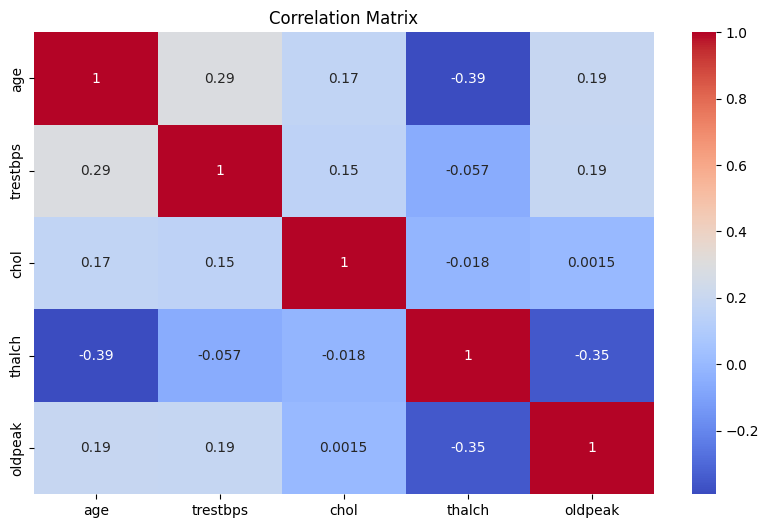

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df_standardized.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Matrix")
plt.show()

The heatmap shows correlations between selected numerical features, which justifies applying PCA.

## 13. PCA Decision

PCA is applied only if numerical features show correlation.

Since the correlation heatmap shows relationships between numerical features, PCA can be applied to reduce dimensionality.

In [102]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(df_standardized[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']])

In [103]:
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.35722545 0.22181821]


In [104]:
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df.head()

,PC1,PC2
0,1.280187,-0.114340
1,2.730341,0.631474
2,1.542083,-1.205460
3,-0.946256,-0.261656
4,-1.416594,-0.533737


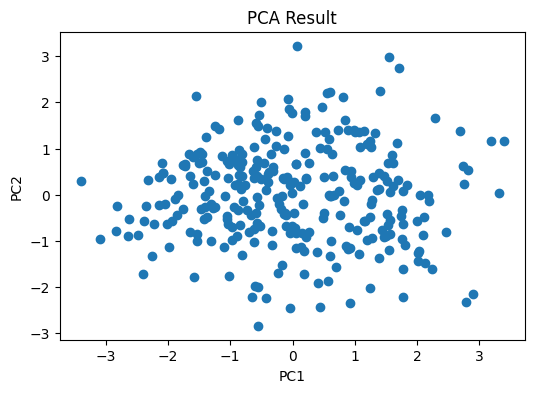

In [105]:
plt.figure(figsize=(6,4))
plt.scatter(pca_df["PC1"], pca_df["PC2"])
plt.title("PCA Result")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### PCA Interpretation

PC1 explains the largest portion of the variance in the dataset, meaning it captures the most important patterns in the data.

PC2 explains additional variance but less than PC1, indicating it contributes secondary information.

This shows that the dataset can be represented in fewer dimensions while preserving a significant amount of information.

---

### Important Note

Although PCA is typically applied when features are strongly correlated, the correlation between the numerical features in this dataset is weak.

Therefore, PCA is applied here mainly for demonstration purposes rather than necessity.
